# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [1]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import math 

import sys
from pathlib import Path

import hashlib
from datetime import datetime
from types import SimpleNamespace

root = Path.cwd()
print(root)

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from utils_experiment import * 
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

root = Path.cwd()
print(root) 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence
device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Data preprocessing

In [2]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n = 256
Data = split_periodize_reshape(Data, n)

for j in range(0):
    Data = W.decompose(Data)[1]

n1 = 100000
x1 = normalize(Data[:n1]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

torch.Size([10000, 1, 1800])
Data shape after preprocessing: torch.Size([70000, 1, 256])
x1 shape: torch.Size([70000, 1, 256])


In [3]:
def plot_time_series(Data, N):
    """Show the first N time series (channel 0), max 10 per row."""

    n_cols = min(N, 8)
    n_rows = int(np.ceil(N / n_cols))

    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False
    )

    for i in range(N):
        row = i // n_cols
        col = i % n_cols

        axs[row, col].plot(Data[i, 0].cpu())
        axs[row, col].set_title(f"Index: {i}", fontsize=28)
        axs[row, col].get_xaxis().set_visible(False)

    # Hide unused axes
    for i in range(N, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axs[row, col].set_visible(False)

    plt.tight_layout()
    plt.show()

In [4]:
def add_sample(samples, Data, idx, category):
    """
    Add one sample from Data to the collection.

    Parameters
    ----------
    samples : dict
        Dictionary with keys "typical" and "rare".
    Data : torch.Tensor
        Signals, shape (B, C, T).
    idx : int
        Index of the sample in Data.
    category : str
        Either "typical" or "rare".
    """
    if category not in samples:
        raise ValueError("category must be 'typical' or 'rare'")

    # Store only the selected sample, detached from any computation graph
    samples[category].append(Data[idx].detach().cpu().clone())

    return samples


def save_samples(samples, path):
    """Save the complete sample collection as a .pt file."""
    torch.save(samples, path)
    print(f"Saved {sum(len(v) for v in samples.values())} samples to {path}")

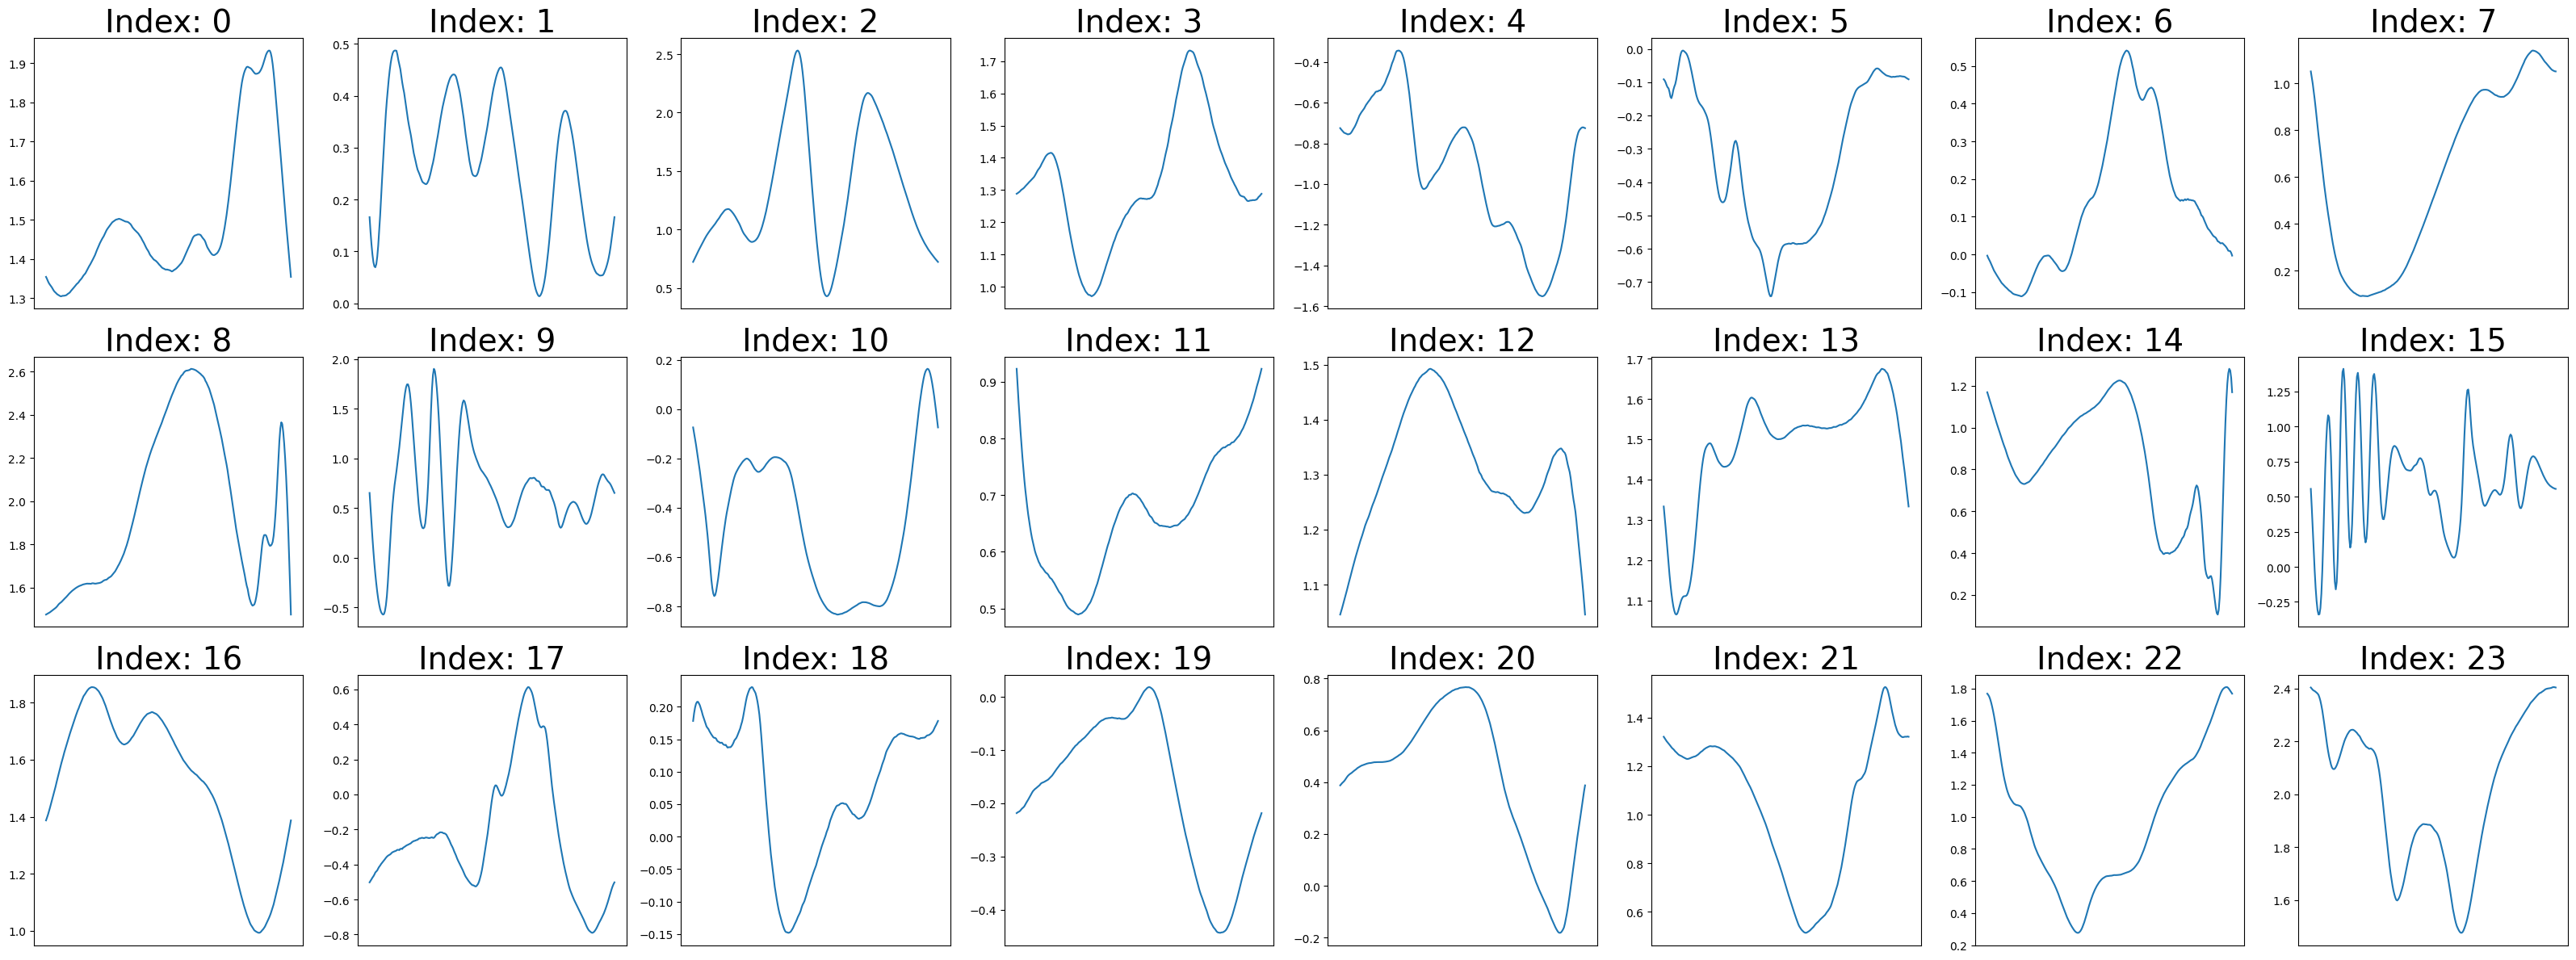

In [5]:
%matplotlib inline 
plot_time_series(x1,24)

## Acceleration distribution and rare-event extraction criterion

"Acceleration" here is the velocity increment at lag tau=1, `a(t) = Data(t+1) - Data(t)`
-- same convention as `check_moments.py`'s velocity-increment PDFs
(`delta u(t, tau) = u(t+tau) - u(t)`), computed on `Data` (post wavelet-decompose,
pre-normalize -- the same stage the hand-picked indices below used to index into).
Rare events are trajectories whose most extreme acceleration (any channel, any
timepoint) exceeds `std_threshold` times the POOLED acceleration std (over the
whole dataset), replacing the hand-picked index lists with a reproducible,
threshold-based criterion.

Pooled acceleration std (all trajectories/channels/timepoints): 0.0404


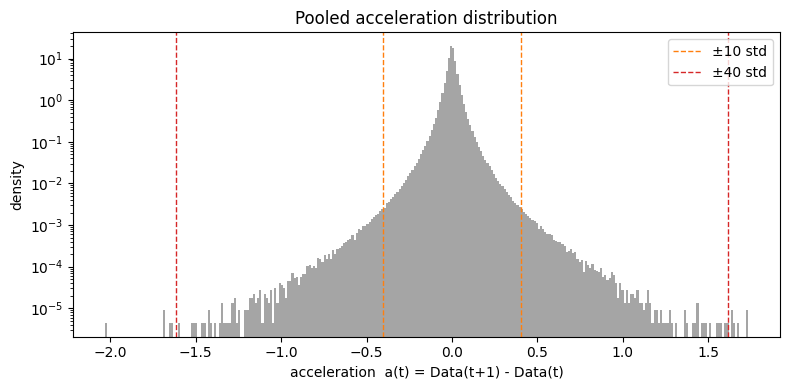

In [6]:
def compute_acceleration(Data):
    """Lagrangian acceleration proxy: velocity increment at lag tau=1,
    a(t) = Data(t+1) - Data(t) -- same convention as check_moments.py's
    velocity-increment PDFs (delta u(t, tau) = u(t+tau) - u(t)) at the
    smallest available lag. No physical dt is defined anywhere for this
    dataset, so this stays in the signal's native (index) units, same as
    every other statistic computed on it in this codebase.
    """
    return Data[..., 1:] - Data[..., :-1]


accel = compute_acceleration(Data)          # (B, C, L-1)
accel_flat = accel.flatten().cpu().numpy()
accel_std = accel_flat.std(ddof=1)
print(f"Pooled acceleration std (all trajectories/channels/timepoints): {accel_std:.4g}")

plt.figure(figsize=(8, 4))
plt.hist(accel_flat, bins=300, density=True, alpha=0.7, color='tab:gray')
plt.yscale('log')
for n_std, color in [(10, 'tab:orange'), (40, 'tab:red')]:
    plt.axvline(n_std * accel_std, color=color, ls='--', lw=1, label=f'±{n_std} std')
    plt.axvline(-n_std * accel_std, color=color, ls='--', lw=1)
plt.xlabel('acceleration  a(t) = Data(t+1) - Data(t)')
plt.ylabel('density')
plt.title('Pooled acceleration distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
def extract_rare_typical(Data, criterion='max_sigma', std_threshold=40,
                          sustained_sigma=10, min_exceedances=3, percentile=95):
    """
    Classify each trajectory (batch index) in `Data` as 'rare' or 'typical',
    from the pooled acceleration distribution a(t) = Data(t+1) - Data(t)
    (see compute_acceleration).

    criterion:
      'max_sigma'       -- rare if the trajectory's single most extreme |a(t)|
                            (any channel/timepoint) exceeds std_threshold * pooled_std.
                            Punctual: one isolated spike is enough to qualify.
      'sustained_sigma' -- rare if at least `min_exceedances` timepoints (pooled
                            over channels) exceed sustained_sigma * pooled_std --
                            requires a repeated/bursty excursion, not a single point.
      'percentile'      -- rare if the trajectory's max |a(t)| is in the top
                            (100 - percentile)% of all trajectories' max |a(t)| --
                            a relative cutoff, no sigma multiplier involved.

    Returns
    -------
    idx_typical, idx_rare : list[int]
    info : dict of diagnostic values (pooled std, threshold(s) used, etc.)
    """
    accel = compute_acceleration(Data)                                # (B, C, L-1)
    accel_std = accel.flatten().std(unbiased=True).item()
    B = accel.shape[0]
    reduce_dims = tuple(range(1, accel.ndim))
    per_traj_max_abs_accel = accel.abs().amax(dim=reduce_dims)        # (B,)

    if criterion == 'max_sigma':
        is_rare = per_traj_max_abs_accel > std_threshold * accel_std
        info = dict(accel_std=accel_std, threshold=std_threshold * accel_std)

    elif criterion == 'sustained_sigma':
        exceed_mask = accel.abs() > sustained_sigma * accel_std       # (B, C, L-1)
        per_traj_exceed_count = exceed_mask.reshape(B, -1).sum(dim=1)  # (B,)
        is_rare = per_traj_exceed_count >= min_exceedances
        info = dict(accel_std=accel_std, threshold=sustained_sigma * accel_std,
                    min_exceedances=min_exceedances,
                    exceed_counts=per_traj_exceed_count)

    elif criterion == 'percentile':
        cutoff = np.percentile(per_traj_max_abs_accel.cpu().numpy(), percentile)
        is_rare = per_traj_max_abs_accel > cutoff
        info = dict(accel_std=accel_std, percentile=percentile, cutoff=cutoff)

    else:
        raise ValueError(f"unknown criterion '{criterion}'")

    idx_rare = torch.nonzero(is_rare).flatten().tolist()
    idx_typical = torch.nonzero(~is_rare).flatten().tolist()
    return idx_typical, idx_rare, info

In [8]:
results_by_criterion = {}
for name, kwargs in [
    ('max_sigma',       dict(criterion='max_sigma', std_threshold=40)),
    ('sustained_sigma', dict(criterion='sustained_sigma', sustained_sigma=20, min_exceedances=8)),
    ('percentile',      dict(criterion='percentile', percentile=99.5)),
]:
    idx_t, idx_r, info = extract_rare_typical(Data, **kwargs)
    results_by_criterion[name] = (idx_t, idx_r, info)
    log_info = {k: v for k, v in info.items() if k != 'exceed_counts'}
    print(f"{name:16s} -> typical {len(idx_t):4d}, rare {len(idx_r):4d}   {log_info}")

max_sigma        -> typical 69992, rare    8   {'accel_std': 0.04039542376995087, 'threshold': 1.6158169507980347}
sustained_sigma  -> typical 69981, rare   19   {'accel_std': 0.04039542376995087, 'threshold': 0.8079084753990173, 'min_exceedances': 8}
percentile       -> typical 69650, rare  350   {'accel_std': 0.04039542376995087, 'percentile': 99.5, 'cutoff': np.float32(0.6311817)}


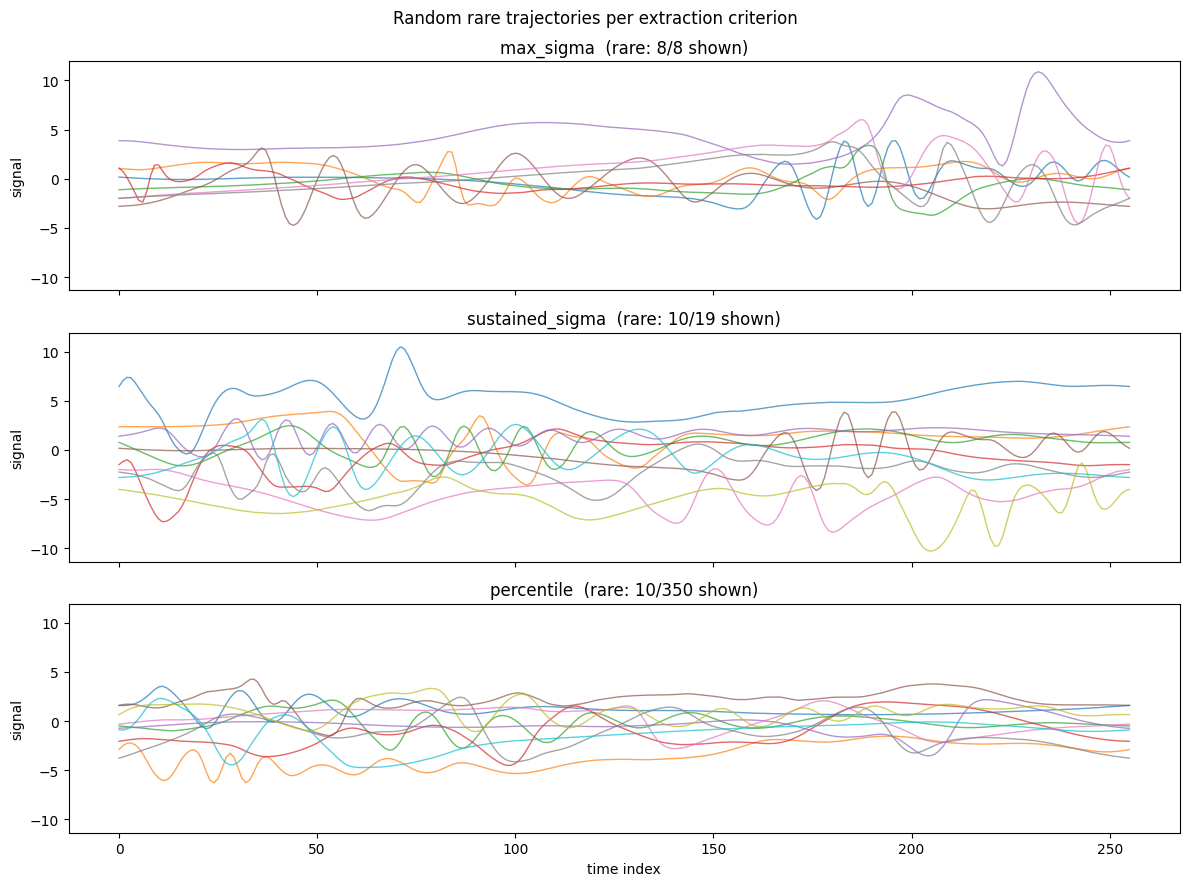

In [9]:
def plot_criterion_comparison(Data, results_by_criterion, n_samples=10,
                               category='rare', seed=None, channel=0):
    """
    Compare rare/typical-event selections across extraction criteria: one
    panel per criterion in `results_by_criterion` (as returned by looping
    extract_rare_typical over 'max_sigma' / 'sustained_sigma' / 'percentile'),
    each showing up to `n_samples` randomly chosen trajectories from that
    criterion's `category` ('rare' or 'typical') selection.

    Parameters
    ----------
    Data : (B, C, L) tensor -- same one extract_rare_typical was run on.
    results_by_criterion : dict {name: (idx_typical, idx_rare, info)}.
    n_samples : how many random trajectories to plot per panel (fewer if
        the criterion selected less than that).
    category : 'rare' or 'typical' -- which selection to visualize.
    seed : optional int, for reproducible random sample choice.
    channel : which channel of Data to plot (Data[idx, channel, :]).
    """
    rng = np.random.default_rng(seed)
    cat_pos = {'typical': 0, 'rare': 1}[category]

    names = list(results_by_criterion.keys())
    fig, axes = plt.subplots(len(names), 1, figsize=(12, 3 * len(names)),
                              sharex=True, sharey=True, squeeze=False)
    axes = axes[:, 0]

    for ax, name in zip(axes, names):
        idx_all = results_by_criterion[name][cat_pos]
        n_pick = min(n_samples, len(idx_all))
        if n_pick == 0:
            ax.set_title(f"{name}  ({category}: 0 selected)")
            ax.text(0.5, 0.5, "no trajectories selected", ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            continue

        idx_pick = rng.choice(idx_all, size=n_pick, replace=False)
        for i in idx_pick:
            ax.plot(Data[i, channel].cpu().numpy(), alpha=0.7, lw=1.0)

        ax.set_title(f"{name}  ({category}: {n_pick}/{len(idx_all)} shown)")
        ax.set_ylabel("signal")

    axes[-1].set_xlabel("time index")
    fig.suptitle(f"Random {category} trajectories per extraction criterion")
    fig.tight_layout()
    plt.show()

plot_criterion_comparison(Data, results_by_criterion, n_samples=10, category='rare', seed=0)

In [11]:
samples = {
    "typical": [],
    "rare": [],
}

In [14]:
idx_typical, idx_rare, info = results_by_criterion['percentile']  # <- swap in whichever you pick after checking the plots
print(f"Using: typical {len(idx_typical)}, rare {len(idx_rare)}")

for i in idx_typical[:350]:
    add_sample(samples, Data, idx=i, category="typical")

for k in idx_rare:
    add_sample(samples, Data, idx=k, category="rare")

Using: typical 69650, rare 350


In [51]:
print({key: len(value) for key, value in samples.items()})

{'typical': 8, 'rare': 8}


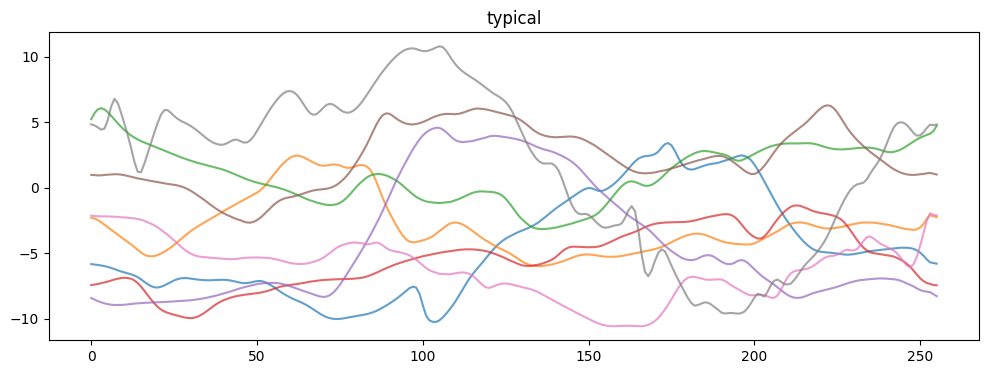

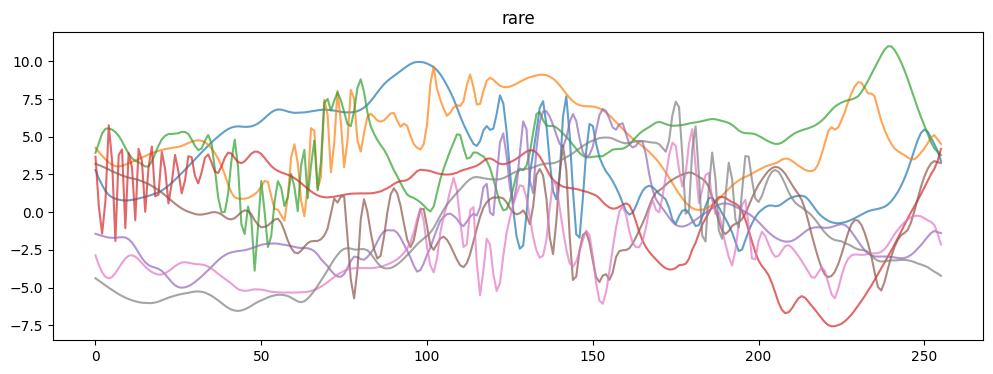

In [52]:
for key, value in samples.items():
    plt.figure(figsize=(12, 4))
    
    for sample in value:
        plt.plot(sample[0].numpy(), alpha=0.7)
    
    plt.title(key)
    plt.show()

In [53]:
save_samples(samples, "selected_samples.pt")

Saved 16 samples to selected_samples.pt
